In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from scipy.stats import entropy, skew, kurtosis
import pickle
from PIL import Image
import seaborn as sns
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
dataroot = "./50k-celeba-dataset-64x64"
workers = 4  # Suitable for better CPU utilization; higher numbers may not give further gains depending on your system
batch_size = 128  # Larger batch size as specified
image_size = 64  # Adjusted back to 64x64 as 1024 may be too large and computationally expensive for batch size 128
nc = 100  # Number of channels for RGB images
nz = 100  # Length of latent vector (noise vector)
ngf = 128  # Generator filters; increased for better image quality with the given batch size
ndf = 128  # Discriminator filters; matched with the generator to balance model capacity
num_epochs = 60 # Shorter training duration for initial testing; can be extended later
lr = 0.0001  # Learning rate adjusted to default value for stable GAN training with Adam
beta1 = 0.5  # Beta1 for Adam optimizer; generally stable for GANs
ngpu = 1  # Number of GPUs available
k_clusters = 40

In [4]:
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.in_channels = in_channels
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, C, width, height = x.size()
        query = self.query(x).view(batch_size, -1, width * height)
        key = self.key(x).view(batch_size, -1, width * height)
        value = self.value(x).view(batch_size, -1, width * height)

        attention = torch.bmm(query.permute(0, 2, 1), key)
        attention = F.softmax(attention, dim=-1)

        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(batch_size, C, width, height)

        out = self.gamma * out + x
        return out


In [5]:

class Generator(nn.Module):
    def __init__(self, nz=100, ngf=128, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [6]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=128):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [7]:
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=workers,persistent_workers=False)

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
netG = Generator(nc=3).to(device)
netD = Discriminator(nc=3).to(device)

Using device: cuda:0


In [9]:
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [10]:
kmeans = MiniBatchKMeans(n_clusters=k_clusters)

In [11]:
G_losses, D_losses, img_list = [], [], []
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1
fake_label = 0

In [12]:
def evaluate_gan_performance(real_images, fake_images, discriminator, threshold=0.5):
    # Move real and fake images to the same device as discriminator
    real_images = real_images.to(device)
    fake_images = fake_images.to(device)

    # Generate labels
    real_labels = np.ones(real_images.size(0))
    fake_labels = np.zeros(fake_images.size(0))

    # Get discriminator predictions
    real_preds = discriminator(real_images).detach().cpu().numpy()
    fake_preds = discriminator(fake_images).detach().cpu().numpy()

    # Flatten predictions (convert from [batch_size, 1, 1, 1] to [batch_size])
    real_preds = real_preds.flatten()
    fake_preds = fake_preds.flatten()

    # Convert predictions to binary labels based on the threshold
    real_preds_binary = (real_preds > threshold).astype(int)
    fake_preds_binary = (fake_preds > threshold).astype(int)

    # Concatenate real and fake labels
    y_true = np.concatenate([real_labels, fake_labels]).astype(int)
    y_pred = np.concatenate([real_preds_binary, fake_preds_binary]).astype(int)

    # Compute confusion matrix and other metrics
    conf_matrix = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, np.concatenate([real_preds, fake_preds]))  # Use raw preds for AUC

    return conf_matrix, precision, recall, f1, roc_auc



In [13]:
def entropy_analysis(real_images, fake_images, num_bins=256):
    # Convert images to numpy and flatten
    real_images = real_images.detach().cpu().numpy().flatten()
    fake_images = fake_images.detach().cpu().numpy().flatten()

    # Normalize pixel values to a probability distribution (histogram)
    real_hist, _ = np.histogram(real_images, bins=num_bins, range=(0, 1), density=True)
    fake_hist, _ = np.histogram(fake_images, bins=num_bins, range=(0, 1), density=True)

    # Add a small epsilon to avoid log(0) issues
    epsilon = 1e-10
    real_hist += epsilon
    fake_hist += epsilon

    # Normalize histograms (so the sum of probabilities equals 1)
    real_hist /= real_hist.sum()
    fake_hist /= fake_hist.sum()

    # Compute the entropy for real and fake images
    real_entropy = entropy(real_hist)
    fake_entropy = entropy(fake_hist)

    return real_entropy, fake_entropy


In [14]:
def compute_uaci(real_images, fake_images):
    # Determine the minimum batch size to avoid shape mismatches
    min_batch_size = min(real_images.size(0), fake_images.size(0))
    
    # Compute the UACI metric using the minimum batch size
    uaci = np.mean(np.abs(real_images.detach().cpu().numpy()[:min_batch_size] - fake_images.detach().cpu().numpy()[:min_batch_size]) / 255.0)
    return uaci


In [15]:
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()
    

In [16]:
def generate_and_save_fake_images(generator, num_images, batch_size, nz, device, save_dir):
    """
    Generate and save fake images using the GAN generator.

    Args:
    - generator: The trained generator model.
    - num_images: Total number of fake images to generate.
    - batch_size: Number of images to generate per batch.
    - nz: Size of the latent vector (input to the generator).
    - device: The device (e.g., 'cuda' or 'cpu') on which to perform computations.
    - save_dir: Directory where generated images will be saved.
    """
    os.makedirs(save_dir, exist_ok=True)  # Ensure the save directory exists
    
    start_idx = 1  # Initial image index for naming files
    generator.eval()  # Set the generator to evaluation mode
    
    with torch.no_grad():  # Disable gradient calculation for faster execution
        for i in range(0, num_images, batch_size):
            z = torch.randn(batch_size, nz, 1, 1, device=device)  # Generate latent vectors
            fake_images = generator(z)  # Generate fake images from latent vectors
            
            # Save fake images to the specified directory
            save_fake_images([fake_images], start_idx=start_idx, save_dir=save_dir)
            start_idx += fake_images.size(0)

def save_fake_images(images_list, start_idx, save_dir):
    """
    Save a list of fake images generated by the GAN in RGB format.
    Handles a list of tensors.

    Args:
    - images_list (list of torch.Tensor): List of image tensors.
    - start_idx (int): Starting index for naming the saved images.
    - save_dir (str): Directory where the images will be saved.
    """
    os.makedirs(save_dir, exist_ok=True)

    for images in images_list:
        batch_size = images.size(0)

        for idx in range(batch_size):
            img_tensor = images[idx]

            try:
                # Step 1: Undo normalization if necessary (e.g., normalization mean=0.5, std=0.5)
                img_tensor = img_tensor * 0.5 + 0.5  # Scale to [0, 1]
                
                # Step 2: Convert the tensor to a numpy array and scale to [0, 255]
                img_numpy = img_tensor.detach().cpu().permute(1, 2, 0).numpy()  # (H, W, C)
                img_numpy = np.clip(img_numpy * 255, 0, 255).astype(np.uint8)  # Scale to [0, 255]
                
                # Step 3: Convert numpy array to PIL image in RGB format
                img_pil = Image.fromarray(img_numpy, mode='RGB')
                
                # Step 4: Save the image to the specified directory
                image_id = start_idx + idx
                image_path = f"{save_dir}/fake_image_{image_id:05d}.png"
                img_pil.save(image_path)
                print(f"Saved image: {image_path}")
            
            except Exception as e:
                print(f"Error saving image {idx + start_idx}: {e}")
        start_idx += batch_size


In [17]:
save_dir = "C:/Users/sarat/50k fake image"
os.makedirs(save_dir, exist_ok=True)


In [18]:
conf_matrix_list, precision_list, recall_list, f1_list, roc_auc_list = [], [], [], [], []
mse_loss_list, uaci_list, entropy_real_list, entropy_fake_list = [], [], [], []

precision_list = []
recall_list = []
f1_list = []
roc_auc_list = []

In [ ]:
# Initialize lists to store accumulated real and fake images
real_images_accum = []
fake_images_accum = []

# Function definition
def compute_mse_loss(real_images_list, fake_images_list):
    real_images_list = [img.to('cpu') for img in real_images_list]
    fake_images_list = [img.to('cpu') for img in fake_images_list]
    # Convert lists of tensors to a single tensor
    real_images_flat = torch.cat(real_images_list, dim=0).detach().cpu().numpy().flatten()
    fake_images_flat = torch.cat(fake_images_list, dim=0).detach().cpu().numpy().flatten()

    # Compute the MSE loss
    mse_loss = mean_squared_error(real_images_flat, fake_images_flat)
    return mse_loss

def save_fake_images(images_list, start_idx, save_dir):
    """
    Save a list of fake images generated by the GAN in RGB format.
    Handles a list of tensors.
    
    Args:
    - images_list (list of torch.Tensor): List of image tensors.
    - start_idx (int): Starting index for naming the saved images.
    - save_dir (str): Directory where the images will be saved.
    """
    # Ensure the save directory exists
    os.makedirs(save_dir, exist_ok=True)
    
    # Iterate over the list of image tensors
    for images in images_list:
        batch_size = images.size(0)
        
        for idx in range(batch_size):
            img_tensor = images[idx]
            
            try:
                # Step 1: Undo normalization if necessary (e.g., common normalization mean=0.5, std=0.5)
                img_tensor = img_tensor * 0.5 + 0.5  # Scale to [0, 1]
                
                # Step 2: Convert the tensor to a numpy array and scale to [0, 255]
                img_numpy = img_tensor.detach().cpu().permute(1, 2, 0).numpy()  # (H, W, C) format
                img_numpy = np.clip(img_numpy * 255, 0, 255).astype(np.uint8)  # Scale to [0, 255]
                
                # Step 3: Convert numpy array to PIL image in RGB format
                img_pil = Image.fromarray(img_numpy, mode='RGB')
                
                # Step 4: Save the image to the specified directory
                image_id = start_idx + idx
                image_path = f"{save_dir}/fake_image_{image_id:05d}.png"
                img_pil.save(image_path)
                print(f"Saved image: {image_path}")
            
            except Exception as e:
                print(f"Error saving image {idx + start_idx}: {e}")
        start_idx += batch_size  # Update start_idx after each batch



            # Save the image
        img_pil.save(f"{save_dir}/fake_image_{image_id:05d}.png")

    print(f"Saved {sum([x.size(0) for x in images])} images to {save_dir}")

# Training Loop
for epoch in range(num_epochs):
    real_images_accum = []
    fake_images_accum = []
    for i, data in enumerate(dataloader, 0):
        print(f"Iteration[{i+1}/{epoch+1}]")

        ############################
        # (1) Update Discriminator with real images
        ############################
        netD.zero_grad()
        real_cpu = data[0].to(device)  # Move real images to GPU
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, device=device)  # Move labels to GPU
        output = netD(real_cpu).view(-1)

        # Compute loss for real images and update Discriminator
        errD_real = criterion(output, label.float())
        errD_real.backward()

        ############################
        # (2) Train Discriminator with fake images
        ############################
        noise = torch.randn(b_size, nz, 1, 1, device=device)  # Generate noise on GPU
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label.float())
        errD_fake.backward()
        optimizerD.step()

        ############################
        # (3) Update Generator
        ############################
        netG.zero_grad()
        label.fill_(real_label)  # Set labels for Generator training
        output = netD(fake).view(-1)
        errG = criterion(output, label.float())
        errG.backward()
        optimizerG.step()

        # Ensure the same batch size before MSE computation
        min_batch_size = min(real_cpu.size(0), fake.size(0))
        real_cpu = real_cpu[:min_batch_size]
        fake_images = fake[:min_batch_size]

        # Save losses for plotting
        G_losses.append(errG.item())
        D_losses.append(errD_real.item() + errD_fake.item())

        # Accumulate real and fake images
        real_images_accum.append(real_cpu.detach().cpu())
        fake_images_accum.append(fake.detach().cpu())

    # Only save images after the final epoch
    if epoch == num_epochs - 1:  # Save and visualize after the final epoch
        with torch.no_grad():
            fake_images = netG(fixed_noise).detach()
            real_images_accum.append(real_cpu[:64].clone())
            fake_images_accum.append(fake[:64].clone())
            save_fake_images(fake_images_accum, start_idx=1, save_dir= "C:/Users/sarat/50k fake image")
            # Calculate the MSE loss after training
            final_mse_loss = compute_mse_loss(real_images_accum, fake_images_accum)
            print(f"Final MSE Loss: {final_mse_loss:.4f}")
            real_images = next(iter(dataloader))[0]  # Access the first element, which is the image tensor
            fake_images = netG(torch.randn(real_images.size(0), nz, 1, 1, device=device))  # Generate fake images


            # Evaluate GAN performance
            conf_matrix, precision, recall, f1, roc_auc = evaluate_gan_performance(real_images, fake_images, netD)

            # Print the results
            print("Final Epoch Confusion Matrix:")
            print(conf_matrix)
            print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")
            plt.figure(figsize=(8, 6))
            sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
            plt.ylabel('Actual')
            plt.xlabel('Predicted')
            plt.title('Confusion Matrix')
            plt.show()

            

        # Generate grid for real and fake images
        real_images_grid = vutils.make_grid(real_cpu[:64], padding=2, normalize=True)
        fake_images_grid = vutils.make_grid(fake[:64], padding=2, normalize=True)

        # Plotting the real and fake images side by side
        plt.figure(figsize=(15, 15))

        # Real Images
        plt.subplot(1, 2, 1)
        plt.axis("off")
        plt.title("Real Images")
        plt.imshow(np.transpose(real_images_grid.cpu(), (1, 2, 0)))  # Convert to (H, W, C) for plotting

        # Fake Images
        plt.subplot(1, 2, 2)
        plt.axis("off")
        plt.title("Fake Images")
        plt.imshow(np.transpose(fake_images_grid.cpu(), (1, 2, 0)))

        # Show the plot
        plt.show()

    # Evaluate metrics after each epoch
    conf_matrix, precision, recall, f1, roc_auc = evaluate_gan_performance(real_cpu[:64], fake_images[:64], netD)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    roc_auc_list.append(roc_auc)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, AUC: {roc_auc:.4f}")

    mse_loss = compute_mse_loss(real_images_accum, fake_images_accum)
    fake_images_np = fake_images.detach().cpu().numpy().reshape(fake_images.size(0), -1)
    kmeans.partial_fit(fake_images_np)
    centroids = kmeans.cluster_centers_

    # Additional metrics
    real_entropy, fake_entropy = entropy_analysis(real_cpu, fake_images)
    uaci = compute_uaci(real_cpu, fake_images)

    # Append metrics to lists for visualization later
    conf_matrix_list.append(conf_matrix)
    mse_loss_list.append(mse_loss)
    uaci_list.append(uaci)
    entropy_real_list.append(real_entropy)
    entropy_fake_list.append(fake_entropy)
    print("Clearing memory")
    torch.cuda.empty_cache()
    print("Memory Cleared")

print("Training completed. Generating 50,000 fake images...")

# Call the function to generate and save 50,000 fake images
generate_and_save_fake_images(generator=netG, num_images=50000, batch_size=batch_size, nz=nz, device=device,save_dir = save_dir)

print("All fake images saved successfully!")


Iteration[1/1]
Iteration[2/1]
Iteration[3/1]
Iteration[4/1]
Iteration[5/1]
Iteration[6/1]
Iteration[7/1]
Iteration[8/1]
Iteration[9/1]
Iteration[10/1]
Iteration[11/1]
Iteration[12/1]
Iteration[13/1]
Iteration[14/1]
Iteration[15/1]
Iteration[16/1]
Iteration[17/1]
Iteration[18/1]
Iteration[19/1]
Iteration[20/1]
Iteration[21/1]
Iteration[22/1]
Iteration[23/1]
Iteration[24/1]
Iteration[25/1]
Iteration[26/1]
Iteration[27/1]
Iteration[28/1]
Iteration[29/1]
Iteration[30/1]
Iteration[31/1]
Iteration[32/1]
Iteration[33/1]
Iteration[34/1]
Iteration[35/1]
Iteration[36/1]
Iteration[37/1]
Iteration[38/1]
Iteration[39/1]
Iteration[40/1]
Iteration[41/1]
Iteration[42/1]
Iteration[43/1]
Iteration[44/1]
Iteration[45/1]
Iteration[46/1]
Iteration[47/1]
Iteration[48/1]
Iteration[49/1]
Iteration[50/1]
Iteration[51/1]
Iteration[52/1]
Iteration[53/1]
Iteration[54/1]
Iteration[55/1]
Iteration[56/1]
Iteration[57/1]
Iteration[58/1]
Iteration[59/1]
Iteration[60/1]
Iteration[61/1]
Iteration[62/1]
Iteration[63/1]
I

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1972: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1024 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


Clearing memory
Memory Cleared
Iteration[1/2]
Iteration[2/2]
Iteration[3/2]
Iteration[4/2]
Iteration[5/2]
Iteration[6/2]
Iteration[7/2]
Iteration[8/2]
Iteration[9/2]
Iteration[10/2]
Iteration[11/2]
Iteration[12/2]
Iteration[13/2]
Iteration[14/2]
Iteration[15/2]
Iteration[16/2]
Iteration[17/2]
Iteration[18/2]
Iteration[19/2]
Iteration[20/2]
Iteration[21/2]
Iteration[22/2]
Iteration[23/2]
Iteration[24/2]
Iteration[25/2]
Iteration[26/2]
Iteration[27/2]
Iteration[28/2]
Iteration[29/2]
Iteration[30/2]
Iteration[31/2]
Iteration[32/2]
Iteration[33/2]
Iteration[34/2]
Iteration[35/2]
Iteration[36/2]
Iteration[37/2]
Iteration[38/2]
Iteration[39/2]
Iteration[40/2]
Iteration[41/2]
Iteration[42/2]
Iteration[43/2]
Iteration[44/2]
Iteration[45/2]
Iteration[46/2]
Iteration[47/2]
Iteration[48/2]
Iteration[49/2]
Iteration[50/2]
Iteration[51/2]
Iteration[52/2]
Iteration[53/2]
Iteration[54/2]
Iteration[55/2]
Iteration[56/2]
Iteration[57/2]
Iteration[58/2]
Iteration[59/2]
Iteration[60/2]
Iteration[61/2]
It

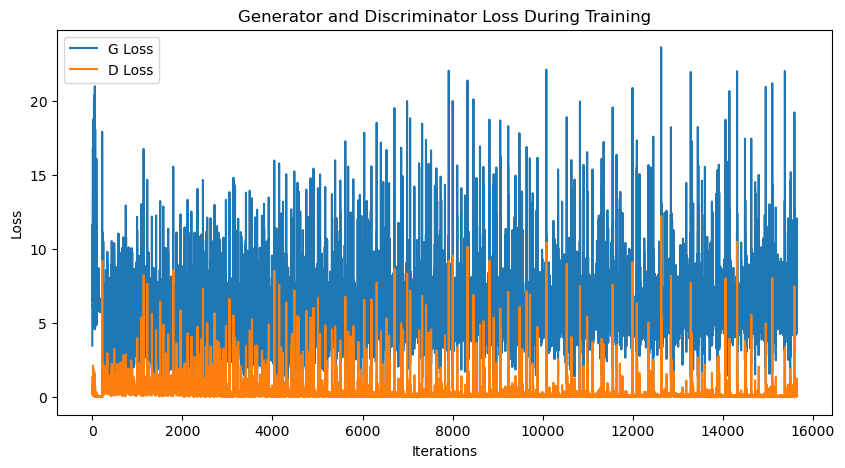

In [23]:
# =======================
# Visualization After Training
# =======================
# Plot Generator and Discriminator Losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [22]:

print("entropy_real_list:", entropy_real_list)
print("entropy_fake_list:", entropy_fake_list)




entropy_real_list: [4.801794342406159, 4.8062762484811845, 4.8269737383979106, 4.82150354213864, 4.822456383903312, 4.8221448067834665, 4.819062350133999, 4.816147421560318, 4.824521636485736, 4.814274224272372, 4.797884044226118, 4.821518133169567, 4.827869955638525, 4.817693062223716, 4.803571042850904, 4.804166637807444, 4.811409061300411, 4.775888783063122, 4.825502694118663, 4.81255554751659, 4.7979128328365865, 4.818099488791308, 4.820940531053864, 4.829331281310068, 4.824408679425522, 4.81103816352727, 4.809302313101094, 4.8028000077130955, 4.825704273933061, 4.823840534614901, 4.824144659732678, 4.818450363845171, 4.8128427867555335, 4.811390543051779, 4.826816744951236, 4.811822614825181, 4.807158043162062, 4.815847296234102, 4.801523461495103, 4.79758702502913]
entropy_fake_list: [5.482447323206331, 5.447505810425534, 5.521125807798089, 5.5285172670338785, 5.5030617613663395, 5.532842792582343, 5.529225234821771, 5.49017778580615, 5.527371233261672, 5.478439515958243, 5.48507